# E-Commerce Data Analysis with Pandas

## Python Data Analytics Masterclass

This notebook takes a realistic e-commerce dataset through a complete analytical workflow:

**Load → Inspect → Type → Clean → Transform → Validate → Combine → Aggregate → Analyze → Visualize**

### Topics covered

- Load CSV and Parquet data
- Inspect DataFrames
- Row-wise and column-wise operations
- Assign appropriate data types
- Filter, sort and rename
- Derive analytical columns
- Handle missing values and duplicates
- Treat invalid types and inconsistent categories
- Handle outliers using documented rules
- Merge, join and concatenate
- Validate keys
- Check row counts before and after combining data
- GroupBy and pivot tables
- Create date features
- Compare business segments and trends
- Mean, median and spread
- Distributions, correlation and outliers
- Bar, line and scatter plots
- Histograms and box plots
- Pandas, Matplotlib and Seaborn

> **Formal hypothesis testing is intentionally excluded.** It belongs in the later statistics/ML module.

## 0. Setup

We use:

- **Pandas** for data manipulation and analysis
- **NumPy** for numerical operations
- **Matplotlib** for general plotting
- **Seaborn** for statistical visualizations

The notebook first looks for the dataset beside the notebook and then in the
standard `/mnt/data/ecommerce_analytics_v1` location.

In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", 50)
pd.set_option("display.max_rows", 100)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

sns.set_theme(style="whitegrid")

# Locate the dataset.
candidates = [
    Path("ecommerce_analytics_v1"),
    Path("../ecommerce_analytics_v1"),
    Path("/mnt/data/ecommerce_analytics_v1"),
    Path("."),
]

DATA_DIR = next(
    (
        p for p in candidates
        if (p / "orders.csv").exists()
        and (p / "customers.csv").exists()
    ),
    None
)

if DATA_DIR is None:
    raise FileNotFoundError(
        "Dataset not found. Put the ecommerce_analytics_v1 folder "
        "beside this notebook or update DATA_DIR."
    )

print("Using:", DATA_DIR.resolve())

Using: /mnt/data/ecommerce_analytics_v1


# 1. Load CSV and Parquet Data

A common analytics workflow involves multiple file formats.

- CSV is widely used for interchange.
- Parquet is columnar and efficient for analytical workloads.

The product data may be supplied as `products.parquet`. If the teaching
dataset has not yet been converted to Parquet, the included CSV is used as a
fallback so that **every notebook cell remains executable**.

In [2]:
orders_raw = pd.read_csv(DATA_DIR / "orders.csv")
customers = pd.read_csv(DATA_DIR / "customers.csv")

parquet_path = DATA_DIR / "products.parquet"
products_csv_path = DATA_DIR / "products.csv"

if parquet_path.exists():
    products = pd.read_parquet(parquet_path)
    product_source = "Parquet"
else:
    products = pd.read_csv(products_csv_path)
    product_source = "CSV fallback"

print(f"Products loaded from: {product_source}")
print(f"Orders:    {orders_raw.shape}")
print(f"Customers: {customers.shape}")
print(f"Products:  {products.shape}")

Products loaded from: CSV fallback
Orders:    (15120, 12)
Customers: (2000, 6)
Products:  (150, 5)


### Teaching note

Notice that loading data is not the same as understanding data.

The next step is always **inspection**.

# 2. Inspect the DataFrames

Start with the structure before modifying anything.

Useful first questions:

1. How many rows and columns?
2. What are the column names?
3. What data types were inferred?
4. Are there missing values?
5. What do typical values look like?

In [3]:
display(orders_raw.head())
display(orders_raw.tail())
print("Shape:", orders_raw.shape)
print("Columns:", list(orders_raw.columns))

,order_id,order_date,customer_id,product_id,quantity,unit_price,discount_pct,shipping_cost,shipping_days,payment_method,customer_rating,region
0,ORD-100000,2025-10-16 00:00:00,C11129,P20146,1,"28,192.18",0,163.56,4,Net Banking,3.00,South
1,ORD-100001,2026-02-17 00:00:00,C10976,P20136,2,"22,081.00",10,329.55,3,Credit Card,2.90,East
2,ORD-100002,2025-10-01 00:00:00,C10108,P20145,6,"26,612.92",5,356.56,5,Cash on Delivery,3.50,East
3,ORD-100003,2025-07-07 00:00:00,C10898,P20117,10,"58,156.14",10,145.85,7,Net Banking,3.80,South
4,ORD-100004,2025-11-09 00:00:00,C11301,P20058,5,"15,120.30",5,161.35,3,UPI,4.10,South


,order_id,order_date,customer_id,product_id,quantity,unit_price,discount_pct,shipping_cost,shipping_days,payment_method,customer_rating,region
15115,ORD-114505,2026-02-28 00:00:00,C11422,P20021,4,"8,408.23",10,91.20,3,UPI,NaN,East
15116,ORD-103589,2025-04-27 00:00:00,C10595,P20041,1,"17,343.56",10,112.31,3,Cash on Delivery,4.20,North
15117,ORD-109466,2025-10-02 00:00:00,C10351,P20116,1,"80,206.65",0,139.42,6,Credit Card,3.90,North
15118,ORD-105155,2025-10-14 00:00:00,C11631,P20135,1,"14,341.98",10,102.56,3,Debit Card,4.00,South
15119,ORD-112594,2026-01-21 00:00:00,C11455,P20051,1,"6,141.33",0,68.85,6,UPI,2.80,South


Shape: (15120, 12)
Columns: ['order_id', 'order_date', 'customer_id', 'product_id', 'quantity', 'unit_price', 'discount_pct', 'shipping_cost', 'shipping_days', 'payment_method', 'customer_rating', 'region']


In [4]:
orders_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15120 entries, 0 to 15119
Data columns (total 12 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   order_id         15120 non-null  object 
 1   order_date       15120 non-null  object 
 2   customer_id      15120 non-null  object 
 3   product_id       15120 non-null  object 
 4   quantity         15120 non-null  object 
 5   unit_price       15080 non-null  float64
 6   discount_pct     15120 non-null  int64  
 7   shipping_cost    14939 non-null  float64
 8   shipping_days    15120 non-null  int64  
 9   payment_method   15120 non-null  object 
 10  customer_rating  14742 non-null  float64
 11  region           15000 non-null  object 
dtypes: float64(3), int64(2), object(7)
memory usage: 1.4+ MB


In [5]:
display(orders_raw.describe(include="all").T)

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
order_id,15120,15000,ORD-113402,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
order_date,15120,547,not-a-date,45,NaN,NaN,NaN,NaN,NaN,NaN,NaN
customer_id,15120,2014,C11398,19,NaN,NaN,NaN,NaN,NaN,NaN,NaN
product_id,15120,165,P20120,128,NaN,NaN,NaN,NaN,NaN,NaN,NaN
quantity,15120,12,1,5111,NaN,NaN,NaN,NaN,NaN,NaN,NaN
unit_price,"15,080.00",NaN,NaN,NaN,"18,083.42","22,938.76",186.60,"3,235.19","11,735.18","22,509.62","499,443.81"
discount_pct,"15,120.00",NaN,NaN,NaN,9.22,7.08,0.00,5.00,10.00,15.00,25.00
shipping_cost,"14,939.00",NaN,NaN,NaN,238.37,121.62,30.05,132.21,237.82,343.19,449.95
shipping_days,"15,120.00",NaN,NaN,NaN,3.75,3.57,1.00,2.00,4.00,5.00,89.00
payment_method,15120,8,Cash on Delivery,3031,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [6]:
missing_summary = pd.DataFrame({
    "missing_count": orders_raw.isna().sum(),
    "missing_pct": orders_raw.isna().mean().mul(100).round(2)
}).sort_values("missing_count", ascending=False)

display(missing_summary)

,missing_count,missing_pct
customer_rating,378,2.50
shipping_cost,181,1.20
region,120,0.79
unit_price,40,0.26
product_id,0,0.00
customer_id,0,0.00
order_date,0,0.00
order_id,0,0.00
discount_pct,0,0.00
quantity,0,0.00


## Column-wise and row-wise inspection

Column selection:

```python
df["column"]
df[["column_a", "column_b"]]
```

Row selection:

```python
df.iloc[0]
df.iloc[:5]
```

`.loc[]` is especially useful when selecting rows using labels or conditions.

In [7]:
# Column-wise
display(orders_raw["quantity"].head())
display(orders_raw[["quantity", "unit_price", "discount_pct"]].head())

# Row-wise
display(orders_raw.iloc[0])
display(orders_raw.iloc[:3])

# Conditional row selection
display(orders_raw.loc[orders_raw["shipping_days"] > 30].head())

0     1
1     2
2     6
3    10
4     5
Name: quantity, dtype: object

,quantity,unit_price,discount_pct
0,1,"28,192.18",0
1,2,"22,081.00",10
2,6,"26,612.92",5
3,10,"58,156.14",10
4,5,"15,120.30",5


order_id                    ORD-100000
order_date         2025-10-16 00:00:00
customer_id                     C11129
product_id                      P20146
quantity                             1
unit_price                   28,192.18
discount_pct                         0
shipping_cost                   163.56
shipping_days                        4
payment_method             Net Banking
customer_rating                   3.00
region                           South
Name: 0, dtype: object

,order_id,order_date,customer_id,product_id,quantity,unit_price,discount_pct,shipping_cost,shipping_days,payment_method,customer_rating,region
0,ORD-100000,2025-10-16 00:00:00,C11129,P20146,1,"28,192.18",0,163.56,4,Net Banking,3.00,South
1,ORD-100001,2026-02-17 00:00:00,C10976,P20136,2,"22,081.00",10,329.55,3,Credit Card,2.90,East
2,ORD-100002,2025-10-01 00:00:00,C10108,P20145,6,"26,612.92",5,356.56,5,Cash on Delivery,3.50,East


,order_id,order_date,customer_id,product_id,quantity,unit_price,discount_pct,shipping_cost,shipping_days,payment_method,customer_rating,region
25,ORD-100025,2026-05-06 00:00:00,C10125,P20109,2,"4,733.60",5,143.08,63,Debit Card,4.90,West
757,ORD-100757,2025-08-05 00:00:00,C10149,P20040,1,"3,381.21",5,371.29,71,Debit Card,4.30,North
863,ORD-100863,2026-02-19 00:00:00,C10336,P20087,1,"14,342.57",20,108.37,37,Debit Card,4.30,West
1083,ORD-101083,2026-05-31 00:00:00,C10894,P20028,1,"2,840.96",10,64.25,60,Cash on Delivery,4.70,South
1794,ORD-101794,2025-05-28 00:00:00,C10909,P20081,2,"25,611.86",5,265.26,50,Debit Card,4.00,East


# 3. Make a Working Copy

The raw data should be preserved.

A good analytical habit is:

**raw → cleaned → analytical**

We will keep `orders_raw` unchanged and create `orders`.

In [8]:
orders = orders_raw.copy()

print("Raw rows:", len(orders_raw))
print("Working rows:", len(orders))

Raw rows: 15120
Working rows: 15120


# 4. Assign Appropriate Data Types

Dirty datasets frequently contain:

- numbers stored as text
- dates stored as strings
- inconsistent categorical values

Use `errors="coerce"` when invalid values should become `NaN` and be handled
explicitly later.

This is preferable to silently keeping invalid data.

In [9]:
# Inspect the important columns before conversion.
print(orders[["order_date", "quantity", "unit_price"]].dtypes)

order_date     object
quantity       object
unit_price    float64
dtype: object


In [10]:
orders["order_date"] = pd.to_datetime(
    orders["order_date"],
    errors="coerce"
)

orders["quantity"] = pd.to_numeric(
    orders["quantity"],
    errors="coerce"
)

orders["unit_price"] = pd.to_numeric(
    orders["unit_price"],
    errors="coerce"
)

orders["shipping_cost"] = pd.to_numeric(
    orders["shipping_cost"],
    errors="coerce"
)

orders["discount_pct"] = pd.to_numeric(
    orders["discount_pct"],
    errors="coerce"
)

orders["shipping_days"] = pd.to_numeric(
    orders["shipping_days"],
    errors="coerce"
)

orders["customer_rating"] = pd.to_numeric(
    orders["customer_rating"],
    errors="coerce"
)

print(orders.dtypes)

order_id                   object
order_date         datetime64[ns]
customer_id                object
product_id                 object
quantity                  float64
unit_price                float64
discount_pct                int64
shipping_cost             float64
shipping_days               int64
payment_method             object
customer_rating           float64
region                     object
dtype: object


### What happened to invalid values?

Values such as `"unknown"`, `"N/A"` and `"not-a-date"` cannot be converted.

With `errors="coerce"` they become missing values. That makes them visible and
gives us an opportunity to apply a documented rule.

In [11]:
conversion_missing = pd.DataFrame({
    "missing_after_conversion": orders[
        ["order_date", "quantity", "unit_price"]
    ].isna().sum()
})

display(conversion_missing)

,missing_after_conversion
order_date,45
quantity,39
unit_price,40


# 5. Filter, Sort and Rename

Pandas filtering is based on Boolean conditions.

A useful business question:

> Which high-value orders have large quantities?

In [12]:
high_quantity = orders.loc[
    orders["quantity"].ge(5),
    ["order_id", "quantity", "unit_price", "discount_pct"]
].sort_values("quantity", ascending=False)

display(high_quantity.head(10))

,order_id,quantity,unit_price,discount_pct
3,ORD-100003,10.00,"58,156.14",10
14929,ORD-114929,10.00,"21,833.01",5
14992,ORD-114992,10.00,"10,679.19",0
14989,ORD-114989,10.00,"63,389.11",20
15017,ORD-111119,10.00,"15,638.75",10
12018,ORD-112018,10.00,389.16,5
11664,ORD-111664,10.00,"9,725.17",20
11895,ORD-111895,10.00,"34,739.09",15
11946,ORD-111946,10.00,"14,749.83",0
5395,ORD-105395,10.00,"15,549.94",5


In [13]:
# Multiple conditions
filtered = orders.loc[
    orders["quantity"].ge(3)
    & orders["unit_price"].ge(5000)
]

display(filtered.head(10))
print("Matching rows:", len(filtered))

,order_id,order_date,customer_id,product_id,quantity,unit_price,discount_pct,shipping_cost,shipping_days,payment_method,customer_rating,region
2,ORD-100002,2025-10-01,C10108,P20145,6.00,"26,612.92",5,356.56,5,Cash on Delivery,3.50,East
3,ORD-100003,2025-07-07,C10898,P20117,10.00,"58,156.14",10,145.85,7,Net Banking,3.80,South
4,ORD-100004,2025-11-09,C11301,P20058,5.00,"15,120.30",5,161.35,3,UPI,4.10,South
8,ORD-100008,2026-06-25,C11400,P20062,3.00,"28,885.05",25,313.30,3,Cash on Delivery,4.80,West
12,ORD-100012,2026-04-20,C11827,P20009,3.00,"19,171.11",5,288.52,4,Debit Card,3.20,North
13,ORD-100013,2025-01-06,C10716,P20027,5.00,"11,088.94",5,72.56,1,Net Banking,3.00,West
20,ORD-100020,2025-02-23,C11389,P20060,4.00,"15,509.69",10,33.37,6,Net Banking,3.20,South
27,ORD-100027,2025-10-14,C11860,P20120,3.00,"31,923.51",5,236.34,4,Debit Card,3.30,West
29,ORD-100029,2026-01-16,C10487,P20135,3.00,"10,520.90",5,402.62,3,Credit Card,4.10,East
30,ORD-100030,2025-02-12,C11201,P20030,8.00,"33,459.61",15,111.03,2,Net Banking,4.80,West


Matching rows: 4059


In [14]:
# query() can make business filters easier to read.
query_result = orders.query(
    "quantity >= 3 and unit_price >= 5000"
)

display(query_result.head())

,order_id,order_date,customer_id,product_id,quantity,unit_price,discount_pct,shipping_cost,shipping_days,payment_method,customer_rating,region
2,ORD-100002,2025-10-01,C10108,P20145,6.00,"26,612.92",5,356.56,5,Cash on Delivery,3.50,East
3,ORD-100003,2025-07-07,C10898,P20117,10.00,"58,156.14",10,145.85,7,Net Banking,3.80,South
4,ORD-100004,2025-11-09,C11301,P20058,5.00,"15,120.30",5,161.35,3,UPI,4.10,South
8,ORD-100008,2026-06-25,C11400,P20062,3.00,"28,885.05",25,313.30,3,Cash on Delivery,4.80,West
12,ORD-100012,2026-04-20,C11827,P20009,3.00,"19,171.11",5,288.52,4,Debit Card,3.20,North


In [15]:
# Demonstrate a safe rename.
orders = orders.rename(columns={
    "unit_price": "unit_price",
    "discount_pct": "discount_pct"
})

print("Column names remain explicit and analysis-friendly.")

Column names remain explicit and analysis-friendly.


# 6. Missing Values

Missing values require a **column-specific business decision**.

There is no universally correct:

```python
df.fillna(0)
```

For example:

- Missing rating may mean the customer did not provide a rating.
- Missing shipping cost may require investigation.
- Missing region may be recoverable from the customer master.

First inspect missingness.

In [16]:
missing = pd.DataFrame({
    "count": orders.isna().sum(),
    "percentage": (orders.isna().mean() * 100).round(2)
}).query("count > 0").sort_values("count", ascending=False)

display(missing)

,count,percentage
customer_rating,378,2.50
shipping_cost,181,1.20
region,120,0.79
order_date,45,0.30
unit_price,40,0.26
quantity,39,0.26


### Recover information from a trusted master table

The orders table already has `customer_id`, while the customer master has the
authoritative region.

We will not blindly fill missing region values. We will derive a trusted
region lookup and use it only where the customer exists.

In [17]:
region_lookup = customers.set_index("customer_id")["region"]

orders["region_from_customer"] = orders["customer_id"].map(region_lookup)

missing_region_before = orders["region"].isna().sum()

orders["region"] = orders["region"].fillna(
    orders["region_from_customer"]
)

orders = orders.drop(columns="region_from_customer")

print("Missing region before recovery:", missing_region_before)
print("Missing region after recovery:", orders["region"].isna().sum())

Missing region before recovery: 120
Missing region after recovery: 0


For customer ratings, we will retain missing values rather than inventing
ratings. When calculating rating statistics, pandas will ignore `NaN` by
default.

For shipping cost, we will preserve missing values until the business rule is
defined rather than immediately replacing them.

# 7. Duplicates

First distinguish **exact duplicate records** from legitimate repeated orders.

`duplicated()` identifies rows that are identical across the selected columns.

In [18]:
duplicate_count = orders.duplicated().sum()
print("Exact duplicate rows:", duplicate_count)

display(orders.loc[orders.duplicated(keep=False)].head(10))

Exact duplicate rows: 104


,order_id,order_date,customer_id,product_id,quantity,unit_price,discount_pct,shipping_cost,shipping_days,payment_method,customer_rating,region
149,ORD-100149,2026-02-06,C10804,P20103,1.00,"3,912.02",20,142.67,4,Credit Card,2.90,East
169,ORD-100169,2025-07-07,C10769,P20118,4.00,"9,665.51",0,251.16,2,Debit Card,3.80,South
251,ORD-100251,2025-06-10,C11038,P20083,1.00,"2,142.32",15,312.27,5,UPI,4.30,East
387,ORD-100387,2026-01-15,C10296,P20077,1.00,"3,995.11",15,162.45,7,Debit Card,3.60,North
542,ORD-100542,2026-05-16,C10641,P20076,2.00,"21,072.82",5,101.63,5,Debit Card,3.50,East
764,ORD-100764,2025-12-14,C11075,P20021,2.00,"8,157.87",5,87.20,6,Credit Card,2.60,South
862,ORD-100862,2025-10-03,C11616,P20147,2.00,"19,192.85",20,111.72,7,Cash on Delivery,4.80,South
932,ORD-100932,2025-03-23,C11984,P20085,1.00,"32,256.22",5,252.89,1,Debit Card,3.70,South
1039,ORD-101039,2026-01-16,C11996,P20147,1.00,"14,180.02",10,369.05,6,UPI,3.30,South
1373,ORD-101373,2026-03-22,C11538,P20109,1.00,"5,345.32",15,336.82,1,Debit Card,3.30,East


In [19]:
# Remove exact duplicates.
before = len(orders)
orders = orders.drop_duplicates().copy()
after = len(orders)

print("Rows before:", before)
print("Rows after: ", after)
print("Removed:    ", before - after)

Rows before: 15120
Rows after:  15016
Removed:     104


# 8. Inconsistent Categories

Real datasets often contain values such as:

```text
UPI
upi
UPI 
```

These may represent the same business category.

First inspect the raw categories.

In [20]:
display(orders["payment_method"].value_counts(dropna=False))

payment_method
Cash on Delivery    3015
Credit Card         2991
Net Banking         2979
Debit Card          2943
UPI                 2908
UPI                   60
upi                   60
credit card           60
Name: count, dtype: int64

In [21]:
orders["payment_method"] = (
    orders["payment_method"]
    .astype("string")
    .str.strip()
    .str.lower()
)

payment_map = {
    "upi": "UPI",
    "credit card": "Credit Card",
    "debit card": "Debit Card",
    "net banking": "Net Banking",
    "cash on delivery": "Cash on Delivery",
}

orders["payment_method"] = orders["payment_method"].replace(payment_map)

display(orders["payment_method"].value_counts(dropna=False))

payment_method
Credit Card         3051
UPI                 3028
Cash on Delivery    3015
Net Banking         2979
Debit Card          2943
Name: count, dtype: Int64

The same idea applies to product categories.

The product master is treated as the authoritative source for product
metadata, so we will normalize categories there as well.

In [22]:
products["product_category"] = (
    products["product_category"]
    .astype("string")
    .str.strip()
    .str.title()
)

products["brand"] = (
    products["brand"]
    .astype("string")
    .str.strip()
)

display(products["product_category"].value_counts())

product_category
Fashion           41
Electronics       35
Books             29
Sports            26
Home & Kitchen    19
Name: count, dtype: Int64

# 9. Invalid Values and Business Rules

Some values are technically valid Python values but invalid for the business.

Examples:

- quantity <= 0 may represent cancellation/refund records
- negative shipping days would be invalid
- a shipping time of 80 days deserves investigation
- an extremely high unit price may be a data-entry issue

We will **flag before removing**.

In [23]:
invalid_quantity = orders["quantity"].le(0)
invalid_shipping = orders["shipping_days"].lt(0)

print("Non-positive quantities:", invalid_quantity.sum())
print("Negative shipping days:", invalid_shipping.sum())

display(
    orders.loc[
        invalid_quantity | invalid_shipping,
        ["order_id", "quantity", "shipping_days"]
    ].head(10)
)

Non-positive quantities: 120
Negative shipping days: 0


,order_id,quantity,shipping_days
60,ORD-100060,-1.00,3
188,ORD-100188,-3.00,2
249,ORD-100249,-1.00,4
273,ORD-100273,-2.00,4
285,ORD-100285,-3.00,1
447,ORD-100447,-3.00,2
530,ORD-100530,-2.00,5
760,ORD-100760,-3.00,2
782,ORD-100782,-2.00,4
905,ORD-100905,-2.00,4


### Documented rule for this tutorial

We will treat negative quantity records as **cancellation/refund records** and
exclude them from the primary positive-sales analysis.

We do not delete them from the raw data.

In [24]:
sales_orders = orders.loc[
    orders["quantity"].gt(0)
].copy()

print("Working order rows:", len(orders))
print("Positive-sales rows:", len(sales_orders))

Working order rows: 15016
Positive-sales rows: 14857


# 10. Outliers — Documented Rule

An outlier is not automatically an error.

We will use the **1.5 × IQR rule** as a statistical flag:

- below Q1 − 1.5×IQR
- above Q3 + 1.5×IQR

The flag is used for investigation, not automatic deletion.

In [25]:
q1 = sales_orders["shipping_days"].quantile(0.25)
q3 = sales_orders["shipping_days"].quantile(0.75)
iqr = q3 - q1

lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr

sales_orders["shipping_outlier"] = (
    (sales_orders["shipping_days"] < lower_bound)
    | (sales_orders["shipping_days"] > upper_bound)
)

print(f"Q1: {q1:.2f}")
print(f"Q3: {q3:.2f}")
print(f"IQR: {iqr:.2f}")
print(f"Bounds: {lower_bound:.2f} to {upper_bound:.2f}")
print("Flagged outliers:", sales_orders["shipping_outlier"].sum())

Q1: 2.00
Q3: 5.00
IQR: 3.00
Bounds: -2.50 to 9.50
Flagged outliers: 59


In [26]:
display(
    sales_orders.loc[
        sales_orders["shipping_outlier"],
        ["order_id", "shipping_days", "region"]
    ].sort_values("shipping_days", ascending=False).head(10)
)

,order_id,shipping_days,region
13815,ORD-113815,89,West
12523,ORD-112523,89,South
12340,ORD-112340,89,South
5160,ORD-105160,87,West
2369,ORD-102369,85,North
8452,ORD-108452,84,North
14657,ORD-114657,81,West
12360,ORD-112360,76,East
7082,ORD-107082,76,South
14930,ORD-114930,74,East


# 11. Merge, Join and Validate Keys

We now move from a single DataFrame to a small relational data model.

```text
orders
   |
   +---- customer_id ----> customers
   |
   +---- product_id -----> products
```

Before merging, validate the master keys.

In [27]:
print("Customer IDs unique:", customers["customer_id"].is_unique)
print("Product IDs unique:", products["product_id"].is_unique)

print("Missing customer IDs in orders:",
      sales_orders["customer_id"].isna().sum())

print("Missing product IDs in orders:",
      sales_orders["product_id"].isna().sum())

Customer IDs unique: True
Product IDs unique: True
Missing customer IDs in orders: 0
Missing product IDs in orders: 0


In [28]:
# Referential-integrity checks
valid_customer_ids = set(customers["customer_id"])
valid_product_ids = set(products["product_id"])

orphan_customers = sorted(
    set(sales_orders["customer_id"].dropna()) - valid_customer_ids
)
orphan_products = sorted(
    set(sales_orders["product_id"].dropna()) - valid_product_ids
)

print("Orphan customer IDs:", len(orphan_customers))
print("Orphan product IDs:", len(orphan_products))

Orphan customer IDs: 14
Orphan product IDs: 15


### Why row counts matter

A many-to-one merge should not unexpectedly multiply transaction rows.

We record the row count before and after the merge.

In [29]:
before_merge = len(sales_orders)

orders_customers = sales_orders.merge(
    customers,
    on="customer_id",
    how="left",
    validate="many_to_one",
    indicator=True,
    suffixes=("", "_customer")
)

after_merge = len(orders_customers)

print("Before merge:", before_merge)
print("After merge: ", after_merge)
print("Difference:  ", after_merge - before_merge)

display(orders_customers["_merge"].value_counts())

Before merge: 14857
After merge:  14857
Difference:   0


_merge
both          14843
left_only        14
right_only        0
Name: count, dtype: int64

`validate="many_to_one"` is an important production-quality habit.

It tells pandas that many order rows may belong to one customer, but each
customer key should identify at most one customer record.

In [30]:
# Remove the merge diagnostic after inspection.
orders_customers = orders_customers.drop(columns="_merge")

### Merge products

Because the dataset intentionally contains a few orphan product IDs, a left
join preserves the transaction rows while making the missing product matches
visible.

In [31]:
before_product_merge = len(orders_customers)

analytics = orders_customers.merge(
    products,
    on="product_id",
    how="left",
    validate="many_to_one",
    indicator=True,
    suffixes=("", "_product")
)

after_product_merge = len(analytics)

print("Before product merge:", before_product_merge)
print("After product merge: ", after_product_merge)
print("Difference:          ", after_product_merge - before_product_merge)

display(analytics["_merge"].value_counts())

Before product merge: 14857
After product merge:  14857
Difference:           0


_merge
both          14842
left_only        15
right_only        0
Name: count, dtype: int64

In [32]:
unmatched_products = analytics["_merge"].eq("left_only").sum()
print("Orders without a matching product:", unmatched_products)

analytics = analytics.drop(columns="_merge")

Orders without a matching product: 15


### `concat()`

`concat()` is useful when datasets have the **same structure** and should be
stacked vertically.

For demonstration, split the analytical data into two batches and recombine.

In [33]:
batch_a = analytics.iloc[:100].copy()
batch_b = analytics.iloc[100:200].copy()

recombined = pd.concat([batch_a, batch_b], ignore_index=True)

print("Batch A:", len(batch_a))
print("Batch B:", len(batch_b))
print("Recombined:", len(recombined))
assert len(recombined) == len(batch_a) + len(batch_b)

Batch A: 100
Batch B: 100
Recombined: 200


# 12. Derive Analytical Columns

Raw transactional fields become business metrics through clear vectorized
operations.

We will calculate:

- gross amount
- discount amount
- net amount
- total amount

In [34]:
analytics["gross_amount"] = (
    analytics["quantity"] * analytics["unit_price"]
)

analytics["discount_amount"] = (
    analytics["gross_amount"]
    * analytics["discount_pct"] / 100
)

analytics["net_amount"] = (
    analytics["gross_amount"]
    - analytics["discount_amount"]
)

analytics["total_amount"] = (
    analytics["net_amount"]
    + analytics["shipping_cost"]
)

display(
    analytics[
        [
            "order_id", "quantity", "unit_price",
            "discount_pct", "gross_amount",
            "discount_amount", "net_amount", "total_amount"
        ]
    ].head()
)

,order_id,quantity,unit_price,discount_pct,gross_amount,discount_amount,net_amount,total_amount
0,ORD-100000,1.00,"28,192.18",0,"28,192.18",0.00,"28,192.18","28,355.74"
1,ORD-100001,2.00,"22,081.00",10,"44,162.00","4,416.20","39,745.80","40,075.35"
2,ORD-100002,6.00,"26,612.92",5,"159,677.52","7,983.88","151,693.64","152,050.20"
3,ORD-100003,10.00,"58,156.14",10,"581,561.40","58,156.14","523,405.26","523,551.11"
4,ORD-100004,5.00,"15,120.30",5,"75,601.50","3,780.07","71,821.43","71,982.78"


Notice that these are vectorized column operations.

We are not writing a Python `for` loop over every row.

This is one of the major reasons pandas is useful for tabular analysis.

# 13. Create Date Features

Dates are more useful after creating analytical features.

We will create:

- year
- month
- month name
- quarter
- day of week
- monthly period

In [35]:
analytics["year"] = analytics["order_date"].dt.year
analytics["month"] = analytics["order_date"].dt.month
analytics["month_name"] = analytics["order_date"].dt.month_name()
analytics["quarter"] = analytics["order_date"].dt.quarter
analytics["day_of_week"] = analytics["order_date"].dt.day_name()
analytics["month_period"] = analytics["order_date"].dt.to_period("M")

display(
    analytics[
        ["order_date", "year", "month", "month_name",
         "quarter", "day_of_week", "month_period"]
    ].head(10)
)

,order_date,year,month,month_name,quarter,day_of_week,month_period
0,2025-10-16,"2,025.00",10.00,October,4.00,Thursday,2025-10
1,2026-02-17,"2,026.00",2.00,February,1.00,Tuesday,2026-02
2,2025-10-01,"2,025.00",10.00,October,4.00,Wednesday,2025-10
3,2025-07-07,"2,025.00",7.00,July,3.00,Monday,2025-07
4,2025-11-09,"2,025.00",11.00,November,4.00,Sunday,2025-11
5,2025-09-03,"2,025.00",9.00,September,3.00,Wednesday,2025-09
6,2026-03-11,"2,026.00",3.00,March,1.00,Wednesday,2026-03
7,2025-01-15,"2,025.00",1.00,January,1.00,Wednesday,2025-01
8,2026-06-25,"2,026.00",6.00,June,2.00,Thursday,2026-06
9,2025-03-18,"2,025.00",3.00,March,1.00,Tuesday,2025-03


# 14. GroupBy — Business Questions

Now we move from data preparation to analysis.

A good analytical question is:

> How much revenue does each business segment generate?

`groupby()` changes the question from "what is each row?" to "what does each
group look like?"

In [36]:
segment_revenue = (
    analytics
    .groupby("segment", observed=True)
    ["total_amount"]
    .sum()
    .sort_values(ascending=False)
)

display(segment_revenue)

segment
Consumer         359,389,900.86
Small Business   161,731,978.79
Corporate        128,969,914.81
Name: total_amount, dtype: float64

In [37]:
segment_summary = (
    analytics
    .groupby("segment", observed=True)
    .agg(
        revenue=("total_amount", "sum"),
        orders=("order_id", "nunique"),
        quantity=("quantity", "sum"),
        average_order_value=("total_amount", "mean"),
        median_order_value=("total_amount", "median"),
        average_rating=("customer_rating", "mean"),
    )
    .sort_values("revenue", ascending=False)
)

display(segment_summary)

,revenue,orders,quantity,average_order_value,median_order_value,average_rating
segment,,,,,,
Consumer,"359,389,900.86",8192,"22,204.00","44,489.96","20,271.73",3.74
Small Business,"161,731,978.79",3753,"10,188.00","43,699.53","18,496.42",3.75
Corporate,"128,969,914.81",2885,"7,976.00","45,300.29","20,007.77",3.75


### Compare regions and categories

In [38]:
region_summary = (
    analytics
    .groupby("region", observed=True)
    .agg(
        revenue=("total_amount", "sum"),
        orders=("order_id", "nunique"),
        average_order_value=("total_amount", "mean")
    )
    .sort_values("revenue", ascending=False)
)

category_summary = (
    analytics
    .groupby("product_category", observed=True)
    .agg(
        revenue=("total_amount", "sum"),
        orders=("order_id", "nunique"),
        average_order_value=("total_amount", "mean")
    )
    .sort_values("revenue", ascending=False)
)

display(region_summary)
display(category_summary)

,revenue,orders,average_order_value
region,,,
East,"168,124,176.82",3850,"44,219.93"
West,"164,939,805.82",3713,"45,164.24"
South,"159,277,504.48",3709,"43,388.04"
North,"158,278,046.40",3572,"45,029.32"


,revenue,orders,average_order_value
product_category,,,
Fashion,"165,077,422.33",4053,"41,290.00"
Electronics,"144,661,050.10",3446,"42,534.86"
Sports,"124,484,553.69",2546,"49,714.28"
Books,"120,446,454.21",2882,"42,291.59"
Home & Kitchen,"95,296,316.41",1902,"50,851.82"


# 15. Pivot Tables

A pivot table is useful when comparing two dimensions simultaneously.

Business question:

> How does revenue vary across region and product category?

In [39]:
region_category_pivot = pd.pivot_table(
    analytics,
    values="total_amount",
    index="region",
    columns="product_category",
    aggfunc="sum",
    fill_value=0,
)

display(region_category_pivot)

product_category,Books,Electronics,Fashion,Home & Kitchen,Sports
region,,,,,
East,"30,529,983.50","32,265,973.41","48,824,239.64","25,074,476.96","31,379,786.38"
North,"28,723,359.74","40,625,860.09","35,503,934.97","23,062,841.74","30,037,330.06"
South,"30,793,847.20","35,168,209.88","40,122,914.33","22,865,027.94","30,314,738.04"
West,"30,399,263.77","36,601,006.72","40,626,333.38","24,293,969.78","32,752,699.22"


In [40]:
segment_region_pivot = pd.pivot_table(
    analytics,
    values="total_amount",
    index="segment",
    columns="region",
    aggfunc="mean",
    fill_value=0,
)

display(segment_region_pivot)

region,East,North,South,West
segment,,,,
Consumer,"43,449.55","46,383.62","43,315.92","45,010.24"
Corporate,"49,691.39","45,467.86","39,548.33","46,615.44"
Small Business,"41,778.41","41,684.15","46,939.21","44,536.58"


# 16. Trends Over Time

Create a monthly revenue table.

A line chart is usually more appropriate than a bar chart when the x-axis is
ordered time.

In [41]:
monthly_sales = (
    analytics
    .dropna(subset=["month_period"])
    .groupby("month_period")
    .agg(
        revenue=("total_amount", "sum"),
        orders=("order_id", "nunique"),
        average_order_value=("total_amount", "mean")
    )
    .sort_index()
)

display(monthly_sales)

,revenue,orders,average_order_value
month_period,,,
2025-01,"34,510,888.09",813,"42,870.67"
2025-02,"36,282,910.13",758,"48,312.80"
2025-03,"36,811,324.42",840,"44,782.63"
2025-04,"39,803,580.59",848,"47,555.05"
2025-05,"36,457,529.57",844,"44,352.23"
2025-06,"37,732,775.59",861,"44,339.34"
2025-07,"34,417,501.26",821,"42,281.94"
2025-08,"36,316,080.57",835,"44,180.15"
2025-09,"36,234,901.52",783,"47,119.51"


In [42]:
monthly_segment = (
    analytics
    .dropna(subset=["month_period"])
    .groupby(["month_period", "segment"], observed=True)
    ["total_amount"]
    .sum()
    .reset_index()
)

display(monthly_segment.head(10))

,month_period,segment,total_amount
0,2025-01,Consumer,"18,664,855.05"
1,2025-01,Corporate,"6,319,039.74"
2,2025-01,Small Business,"9,526,993.30"
3,2025-02,Consumer,"17,869,236.28"
4,2025-02,Corporate,"8,409,843.24"
5,2025-02,Small Business,"9,878,157.39"
6,2025-03,Consumer,"20,231,056.11"
7,2025-03,Corporate,"7,250,553.74"
8,2025-03,Small Business,"9,309,750.79"
9,2025-04,Consumer,"20,602,598.79"


# 17. Mean, Median and Spread

Descriptive statistics help us understand the center and variability of a
variable.

- **Mean** — arithmetic average
- **Median** — middle observation
- **Standard deviation** — typical spread around the mean
- **Minimum / maximum** — observed range
- **Quantiles** — distribution checkpoints

The mean can be strongly affected by extreme observations, while the median
is generally more resistant.

In [43]:
order_value_stats = analytics["total_amount"].describe()

display(order_value_stats)

print("Mean:  ", analytics["total_amount"].mean())
print("Median:", analytics["total_amount"].median())
print("Std:   ", analytics["total_amount"].std())

count      14,640.00
mean       44,441.22
std        74,504.95
min           227.40
25%         6,384.14
50%        19,743.73
75%        52,323.92
max     1,998,336.52
Name: total_amount, dtype: float64

Mean:   44441.224967144815
Median: 19743.728750000002
Std:    74504.95412719142


Compare mean and median by segment. Large differences can be a clue that the
distribution is skewed or contains extreme observations.

In [44]:
segment_center = (
    analytics
    .groupby("segment", observed=True)["total_amount"]
    .agg(["mean", "median", "std", "min", "max"])
)

display(segment_center)

,mean,median,std,min,max
segment,,,,,
Consumer,"44,489.96","20,271.73","71,082.91",227.40,"1,655,895.31"
Corporate,"45,300.29","20,007.77","82,324.22",242.01,"1,998,336.52"
Small Business,"43,699.53","18,496.42","75,548.79",277.21,"1,703,707.46"


# 18. Distributions

Summary statistics alone do not tell the whole story.

A distribution shows how observations are spread.

We will use:

- histogram for shape
- box plot for spread and potential outliers

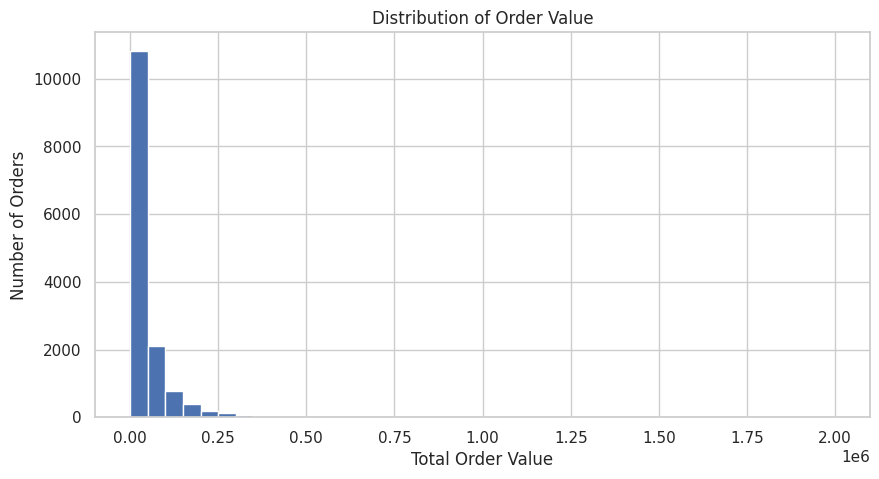

In [45]:
plt.figure(figsize=(10, 5))
plt.hist(
    analytics["total_amount"].dropna(),
    bins=40
)
plt.title("Distribution of Order Value")
plt.xlabel("Total Order Value")
plt.ylabel("Number of Orders")
plt.show()

/tmp/ipykernel_1009/3094679792.py:13: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(groups, labels=labels)


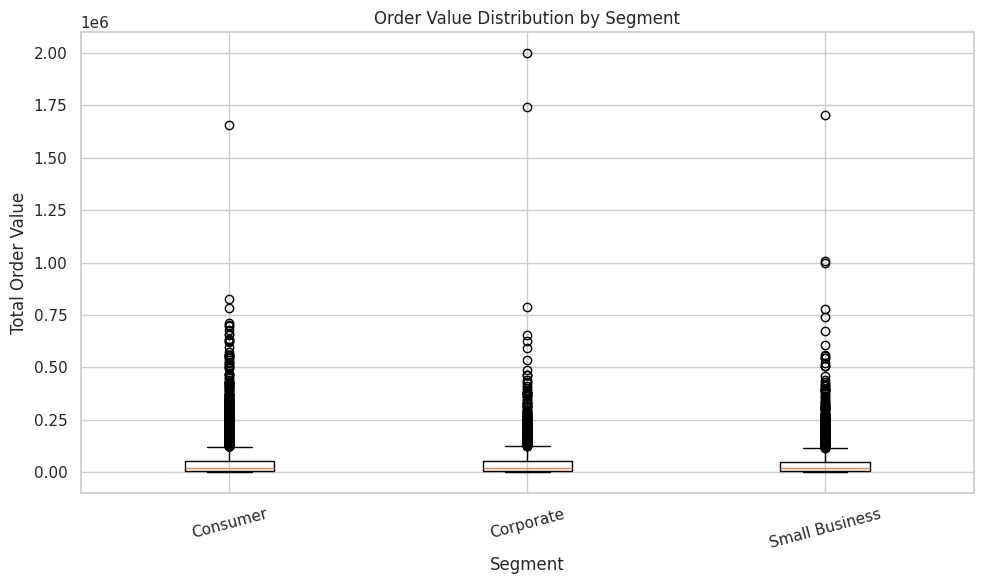

In [46]:
plot_data = analytics[["segment", "total_amount"]].dropna()

groups = [
    group["total_amount"].to_numpy()
    for _, group in plot_data.groupby("segment", observed=True)
]
labels = [
    str(segment)
    for segment, _ in plot_data.groupby("segment", observed=True)
]

plt.figure(figsize=(10, 6))
plt.boxplot(groups, labels=labels)
plt.title("Order Value Distribution by Segment")
plt.xlabel("Segment")
plt.ylabel("Total Order Value")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

# 19. Correlation

Correlation measures the strength of a linear association between numerical
variables.

It does **not** establish causation.

Also note that some relationships may be structural. For example, order
quantity contributes directly to gross revenue.

In [47]:
numeric_columns = [
    "quantity",
    "unit_price",
    "discount_pct",
    "shipping_cost",
    "shipping_days",
    "customer_rating",
    "gross_amount",
    "discount_amount",
    "net_amount",
    "total_amount",
]

correlation = analytics[numeric_columns].corr()

display(correlation.round(2))

,quantity,unit_price,discount_pct,shipping_cost,shipping_days,customer_rating,gross_amount,discount_amount,net_amount,total_amount
quantity,1.00,-0.01,0.00,-0.00,0.01,0.01,0.42,0.30,0.42,0.42
unit_price,-0.01,1.00,0.01,-0.00,0.01,0.01,0.74,0.56,0.74,0.74
discount_pct,0.00,0.01,1.00,0.01,-0.00,-0.01,0.00,0.33,-0.04,-0.04
shipping_cost,-0.00,-0.00,0.01,1.00,-0.00,0.01,-0.00,-0.00,-0.00,-0.00
shipping_days,0.01,0.01,-0.00,-0.00,1.00,-0.00,0.01,0.01,0.01,0.01
customer_rating,0.01,0.01,-0.01,0.01,-0.00,1.00,0.02,0.02,0.02,0.02
gross_amount,0.42,0.74,0.00,-0.00,0.01,0.02,1.00,0.77,1.00,1.00
discount_amount,0.30,0.56,0.33,-0.00,0.01,0.02,0.77,1.00,0.70,0.70
net_amount,0.42,0.74,-0.04,-0.00,0.01,0.02,1.00,0.70,1.00,1.00
total_amount,0.42,0.74,-0.04,-0.00,0.01,0.02,1.00,0.70,1.00,1.00


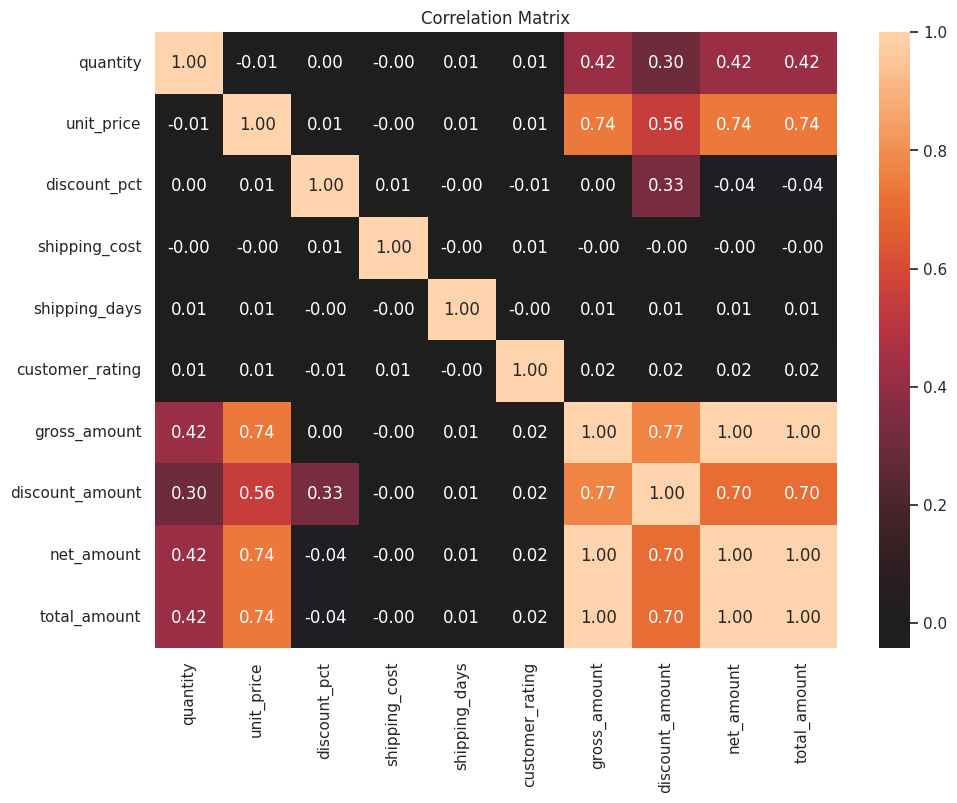

In [48]:
plt.figure(figsize=(11, 8))
sns.heatmap(
    correlation,
    annot=True,
    fmt=".2f",
    center=0
)
plt.title("Correlation Matrix")
plt.show()

# 20. Bar Chart — Business Comparison

Bar charts are appropriate for comparing categories.

Business question:

> How does revenue differ by business segment?

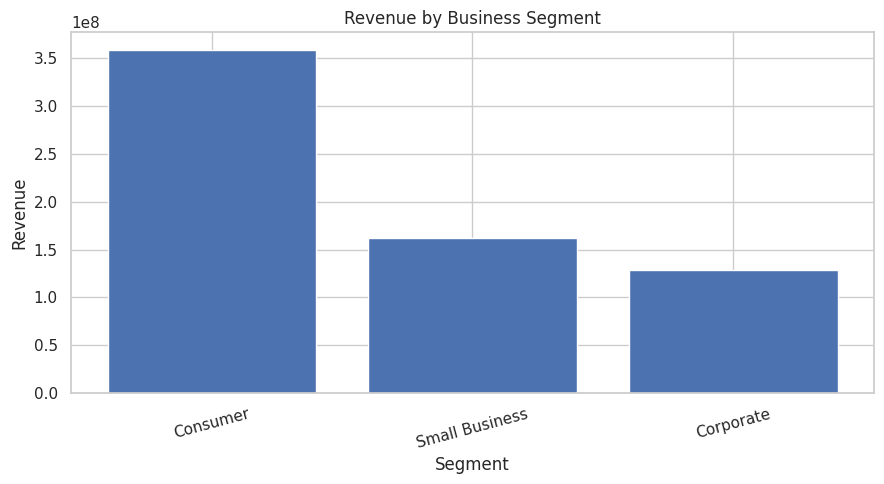

In [49]:
plot_data = segment_summary.reset_index()

plt.figure(figsize=(9, 5))
plt.bar(
    plot_data["segment"].astype(str),
    plot_data["revenue"]
)
plt.title("Revenue by Business Segment")
plt.xlabel("Segment")
plt.ylabel("Revenue")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

# 21. Line Chart — Business Trend

Line charts are appropriate for ordered time data.

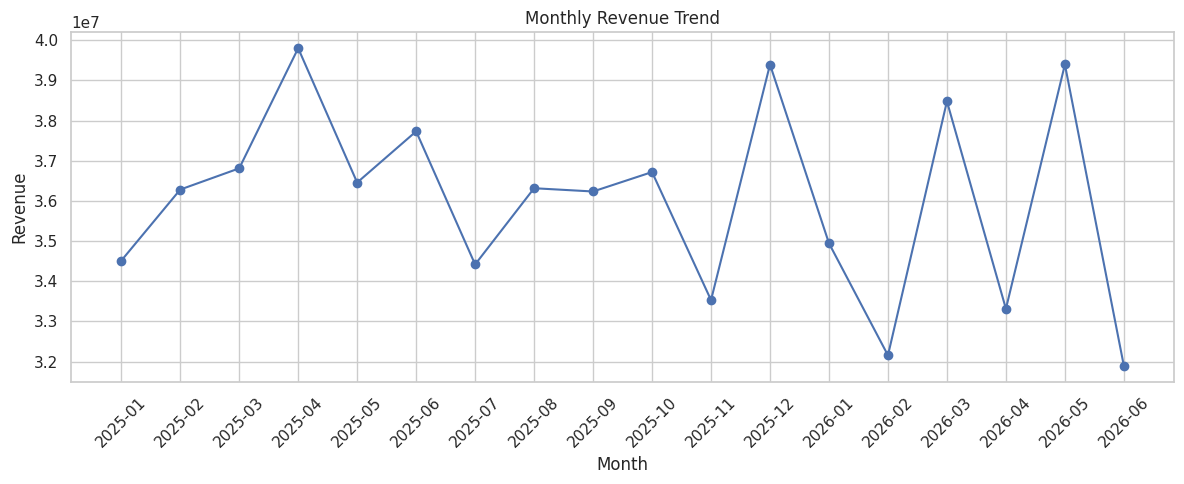

In [50]:
plt.figure(figsize=(12, 5))
plt.plot(
    monthly_sales.index.astype(str),
    monthly_sales["revenue"],
    marker="o"
)
plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Segment trends

A second time-series view helps compare business segments.

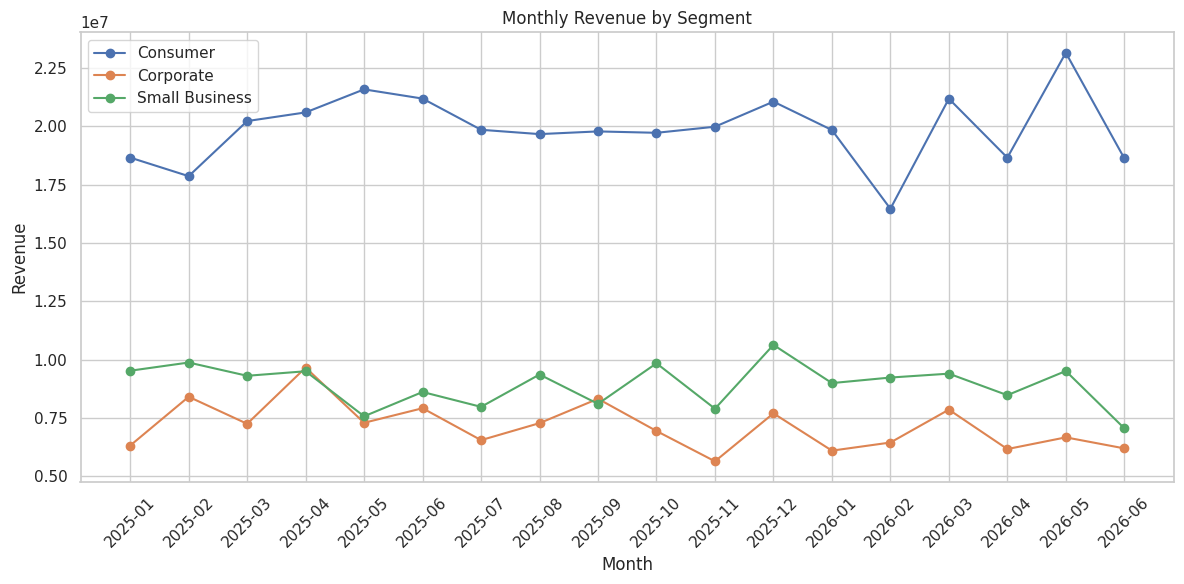

In [51]:
plt.figure(figsize=(12, 6))

for segment, group in monthly_segment.groupby("segment", observed=True):
    plt.plot(
        group["month_period"].astype(str),
        group["total_amount"],
        marker="o",
        label=segment
    )

plt.title("Monthly Revenue by Segment")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

# 22. Scatter Plot — Relationship Between Variables

A scatter plot is useful for exploring relationships between two numerical
variables.

Example:

> Does order quantity tend to increase with order value?

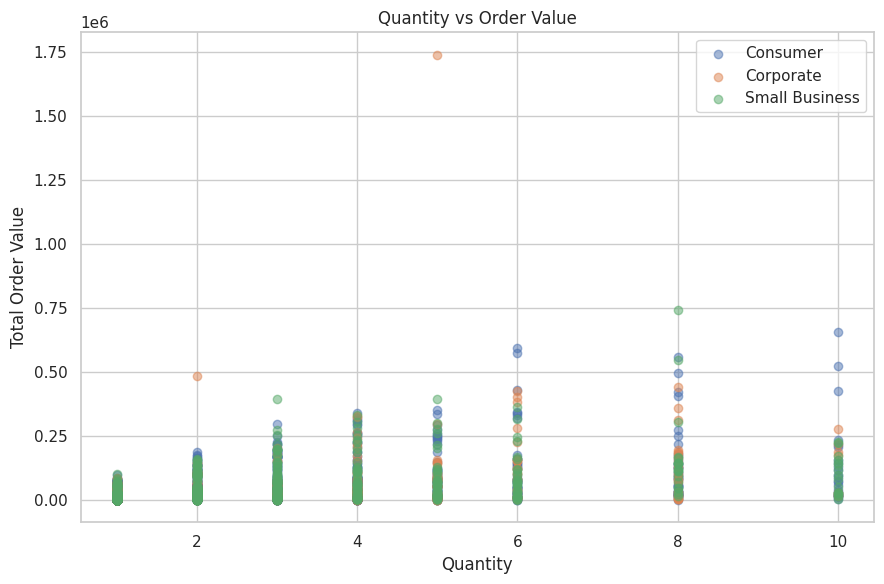

In [52]:
sample = analytics.sample(
    min(3000, len(analytics)),
    random_state=42
)

plt.figure(figsize=(9, 6))

for segment, group in sample.groupby("segment", observed=True):
    plt.scatter(
        group["quantity"],
        group["total_amount"],
        alpha=0.5,
        label=str(segment)
    )

plt.title("Quantity vs Order Value")
plt.xlabel("Quantity")
plt.ylabel("Total Order Value")
plt.legend()
plt.tight_layout()
plt.show()

# 23. Box Plot — Compare Distributions by Segment

Box plots allow us to compare center and spread across categories while also
highlighting potential extreme observations.

/tmp/ipykernel_1009/3094679792.py:13: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(groups, labels=labels)


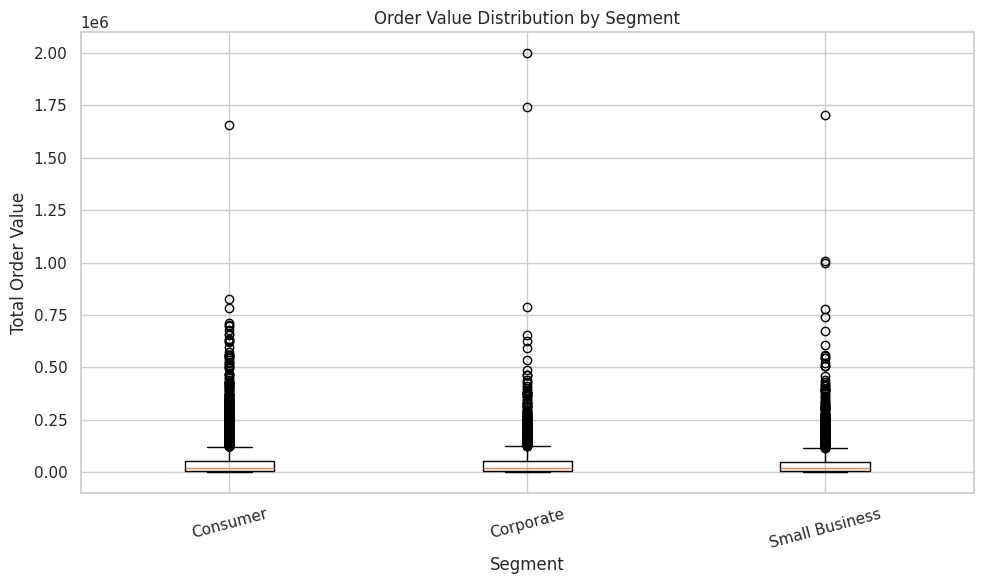

In [53]:
plot_data = analytics[["segment", "total_amount"]].dropna()

groups = [
    group["total_amount"].to_numpy()
    for _, group in plot_data.groupby("segment", observed=True)
]
labels = [
    str(segment)
    for segment, _ in plot_data.groupby("segment", observed=True)
]

plt.figure(figsize=(10, 6))
plt.boxplot(groups, labels=labels)
plt.title("Order Value Distribution by Segment")
plt.xlabel("Segment")
plt.ylabel("Total Order Value")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

# 24. Pandas Plotting

Pandas itself provides convenient plotting wrappers around Matplotlib.

These are excellent for quick exploratory analysis.

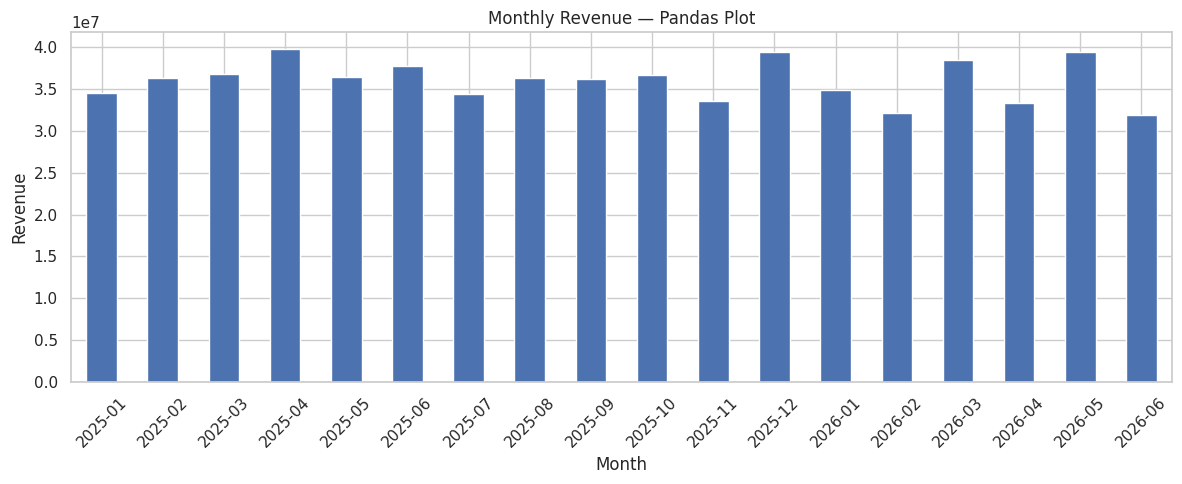

In [54]:
monthly_sales["revenue"].plot(
    kind="bar",
    figsize=(12, 5),
    title="Monthly Revenue — Pandas Plot"
)
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# 25. Data Quality Validation Checklist

Before presenting analysis, run simple assertions.

These checks turn assumptions into executable documentation.

In [55]:
# Basic structural checks
assert len(customers) > 0
assert len(products) > 0
assert analytics["order_id"].notna().all()
assert customers["customer_id"].is_unique
assert products["product_id"].is_unique

# Business-data checks
assert analytics["quantity"].dropna().gt(0).all()
assert analytics["discount_pct"].dropna().between(0, 100).all()
assert analytics["shipping_days"].dropna().ge(0).all()

print("All validation checks passed.")

All validation checks passed.


# 26. Final Analytical Dataset

At this point we have moved from raw transactional data to an analytical
dataset.

A useful final inspection is:

In [56]:
final_columns = [
    "order_id", "order_date", "customer_id", "product_id",
    "segment", "region", "city", "product_category", "brand",
    "quantity", "unit_price", "discount_pct", "shipping_cost",
    "shipping_days", "payment_method", "customer_rating",
    "gross_amount", "discount_amount", "net_amount", "total_amount",
    "year", "month", "quarter", "day_of_week"
]

final_columns = [c for c in final_columns if c in analytics.columns]

display(analytics[final_columns].head())
print("Final analytical shape:", analytics.shape)

,order_id,order_date,customer_id,product_id,segment,region,city,product_category,brand,quantity,unit_price,discount_pct,shipping_cost,shipping_days,payment_method,customer_rating,gross_amount,discount_amount,net_amount,total_amount,year,month,quarter,day_of_week
0,ORD-100000,2025-10-16,C11129,P20146,Corporate,South,Bengaluru,Books,Prime,1.00,"28,192.18",0,163.56,4,Net Banking,3.00,"28,192.18",0.00,"28,192.18","28,355.74","2,025.00",10.00,4.00,Thursday
1,ORD-100001,2026-02-17,C10976,P20136,Small Business,East,Kolkata,Home & Kitchen,Apex,2.00,"22,081.00",10,329.55,3,Credit Card,2.90,"44,162.00","4,416.20","39,745.80","40,075.35","2,026.00",2.00,1.00,Tuesday
2,ORD-100002,2025-10-01,C10108,P20145,Consumer,East,Guwahati,Sports,Orbit,6.00,"26,612.92",5,356.56,5,Cash on Delivery,3.50,"159,677.52","7,983.88","151,693.64","152,050.20","2,025.00",10.00,4.00,Wednesday
3,ORD-100003,2025-07-07,C10898,P20117,Consumer,South,Hyderabad,Home & Kitchen,Vertex,10.00,"58,156.14",10,145.85,7,Net Banking,3.80,"581,561.40","58,156.14","523,405.26","523,551.11","2,025.00",7.00,3.00,Monday
4,ORD-100004,2025-11-09,C11301,P20058,Small Business,South,Bengaluru,Sports,Apex,5.00,"15,120.30",5,161.35,3,UPI,4.10,"75,601.50","3,780.07","71,821.43","71,982.78","2,025.00",11.00,4.00,Sunday


Final analytical shape: (14857, 32)


In [ ]:
analytics.to_csv("analytics.csv", index=False)

# 27. Mini Capstone — Answer the Business Questions

Use the objects created above to investigate:

1. Which segments generate the most revenue?
2. Which regions have the highest order value?
3. Which product categories contribute most revenue?
4. How does revenue change over time?
5. Which segments show different trends?
6. Is the order-value distribution symmetric or skewed?
7. How do mean and median compare?
8. Which variables are correlated?
9. Which observations deserve outlier investigation?
10. What data-quality issues would you report to the business?

## Important

The goal is not simply to produce numbers.

A good analyst should be able to explain:

**What happened? → How do we know? → What data-quality limitations exist? → What should be investigated next?**

Formal hypothesis testing is intentionally left for the statistics/ML module.

# Summary — The Pandas Analytical Workflow

```text
Raw Data
   │
   ├── Load
   │
   ├── Inspect
   │
   ├── Type Conversion
   │
   ├── Missing Values
   │
   ├── Duplicates
   │
   ├── Category Cleaning
   │
   ├── Business Rules
   │
   ├── Outlier Investigation
   │
   ├── Key Validation
   │
   ├── Merge / Join / Concat
   │
   ├── Derived Columns
   │
   ├── Date Features
   │
   ├── GroupBy / Pivot
   │
   ├── Descriptive Statistics
   │
   ├── Distribution / Correlation
   │
   └── Visualization
          │
          ▼
   Business Insights
```

### Core principle

> **Pandas is not the goal. Data understanding is the goal.**

The pandas operations are tools used to move from raw data to trustworthy,
explainable analysis.